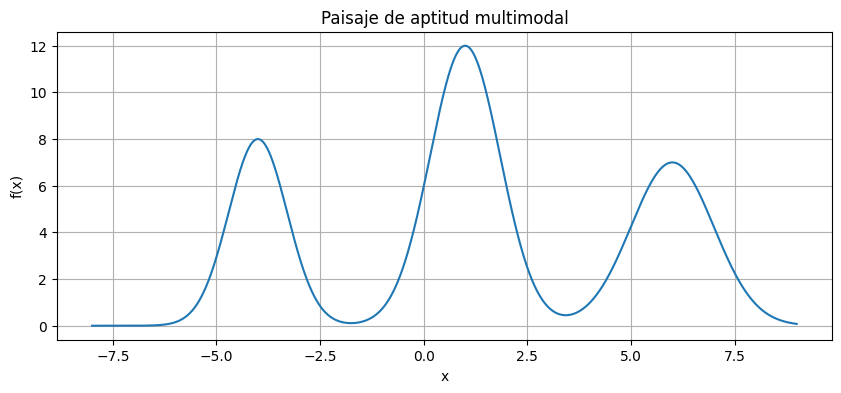

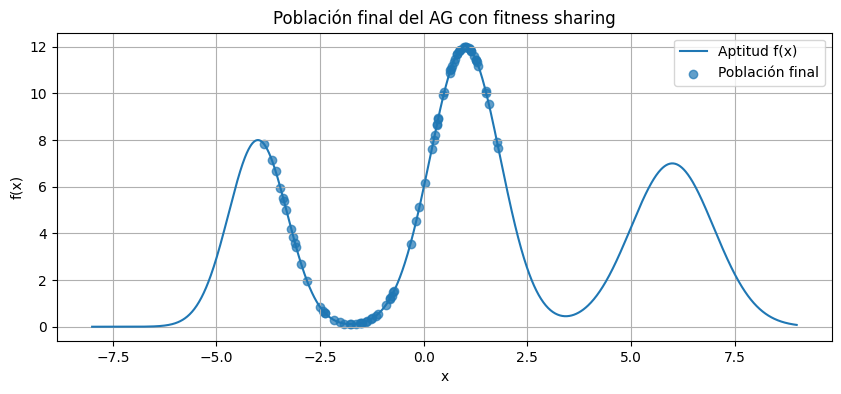

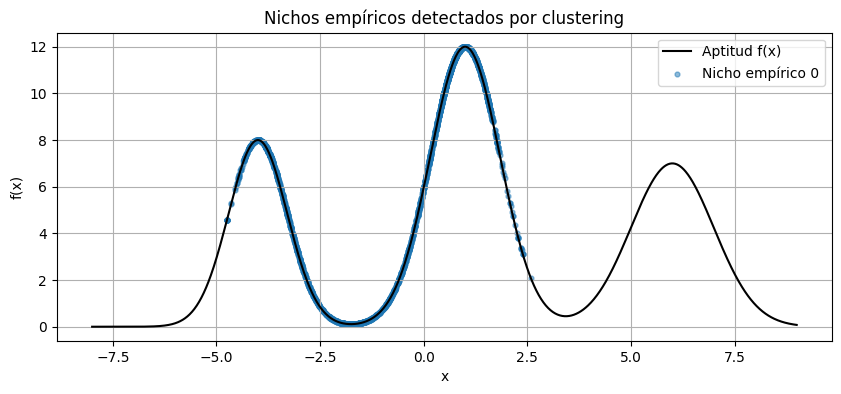

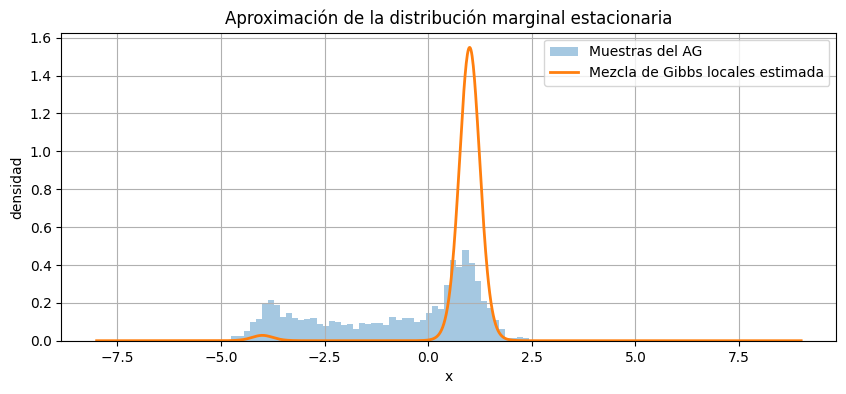

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# -----------------------------
# 1. Paisaje de aptitud
# -----------------------------
def fitness(x):
    return (
        8  * np.exp(-(x + 4)**2)
        + 12 * np.exp(-0.7 * (x - 1)**2)
        + 7  * np.exp(-0.5 * (x - 6)**2)
    )

# -----------------------------
# 2. Fitness sharing
# -----------------------------
def sharing(d, sigma=1.5, alpha=1):
    return np.where(d < sigma, 1 - (d / sigma)**alpha, 0)

def shared_fitness(pop, sigma=1.5):
    raw = fitness(pop)
    distances = np.abs(pop[:, None] - pop[None, :])
    niche_count = sharing(distances, sigma=sigma).sum(axis=1)
    return raw / niche_count

# -----------------------------
# 3. Operadores genéticos
# -----------------------------
def select(pop, fit_values):
    probs = fit_values / fit_values.sum()
    idx = np.random.choice(len(pop), size=len(pop), p=probs)
    return pop[idx]

def crossover(pop, pc=0.8):
    np.random.shuffle(pop)
    children = []

    for i in range(0, len(pop), 2):
        p1, p2 = pop[i], pop[i+1]

        if np.random.rand() < pc:
            a = np.random.rand()
            h1 = a*p1 + (1-a)*p2
            h2 = a*p2 + (1-a)*p1
        else:
            h1, h2 = p1, p2

        children.extend([h1, h2])

    return np.array(children)

def mutate(pop, pm=0.2, sigma_mut=0.35):
    noise = np.random.normal(0, sigma_mut, size=len(pop))
    mask = np.random.rand(len(pop)) < pm
    pop = pop + mask * noise
    return np.clip(pop, -8, 9)

# -----------------------------
# 4. AG con fitness sharing
# -----------------------------
def run_ga(generations=120, mu=80):
    pop = np.random.uniform(-8, 9, mu)
    samples = []

    for t in range(generations):
        fit_values = shared_fitness(pop, sigma=1.5)

        # Guardamos muestras de las últimas generaciones
        if t > generations - 40:
            samples.extend(pop.copy())

        selected = select(pop, fit_values)
        crossed = crossover(selected)
        pop = mutate(crossed)

    return pop, np.array(samples)

np.random.seed(7)
final_pop, samples = run_ga()

# -----------------------------
# 5. Clustering: nichos empíricos
# -----------------------------
X = samples.reshape(-1, 1)

clustering = DBSCAN(eps=0.8, min_samples=10).fit(X)
labels = clustering.labels_

clusters = sorted(set(labels))
clusters = [c for c in clusters if c != -1]

# -----------------------------
# 6. Gibbs locales estimadas
# -----------------------------
beta = 1.0
grid = np.linspace(-8, 9, 1200)
f_grid = fitness(grid)

mixture = np.zeros_like(grid)

for c in clusters:
    cluster_points = samples[labels == c]
    alpha_k = len(cluster_points) / len(samples)

    left = cluster_points.min() - 0.5
    right = cluster_points.max() + 0.5

    mask = (grid >= left) & (grid <= right)

    local_density = np.zeros_like(grid)
    weights = np.exp(beta * f_grid[mask])
    Z = np.trapezoid(weights, grid[mask])

    local_density[mask] = weights / Z
    mixture += alpha_k * local_density

# -----------------------------
# 7. Gráfica 1: paisaje
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(grid, f_grid)
plt.title("Paisaje de aptitud multimodal")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

# -----------------------------
# 8. Gráfica 2: población final
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(grid, f_grid, label="Aptitud f(x)")
plt.scatter(final_pop, fitness(final_pop), alpha=0.7, label="Población final")
plt.title("Población final del AG con fitness sharing")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 9. Gráfica 3: clusters detectados
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(grid, f_grid, color="black", label="Aptitud f(x)")

for c in clusters:
    pts = samples[labels == c]
    plt.scatter(pts, fitness(pts), s=12, alpha=0.5, label=f"Nicho empírico {c}")

plt.title("Nichos empíricos detectados por clustering")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 10. Gráfica 4: mezcla Gibbs local
# -----------------------------
plt.figure(figsize=(10, 4))
plt.hist(samples, bins=50, density=True, alpha=0.4, label="Muestras del AG")
plt.plot(grid, mixture, linewidth=2, label="Mezcla de Gibbs locales estimada")
plt.title("Aproximación de la distribución marginal estacionaria")
plt.xlabel("x")
plt.ylabel("densidad")
plt.legend()
plt.grid(True)
plt.show()

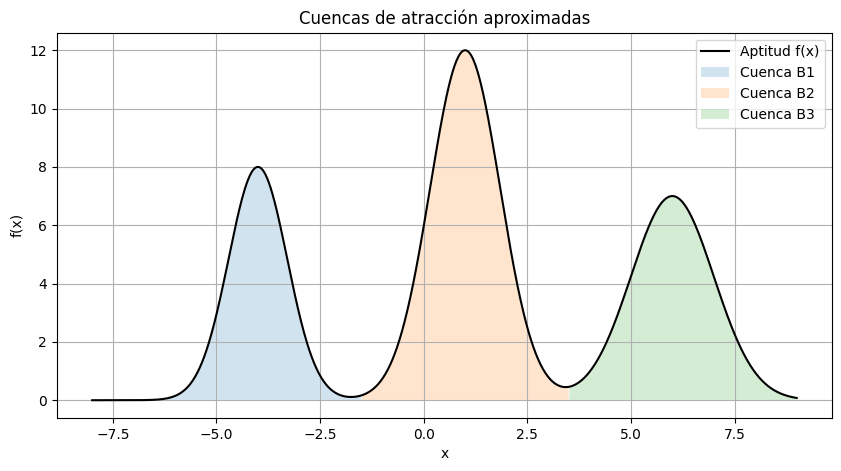

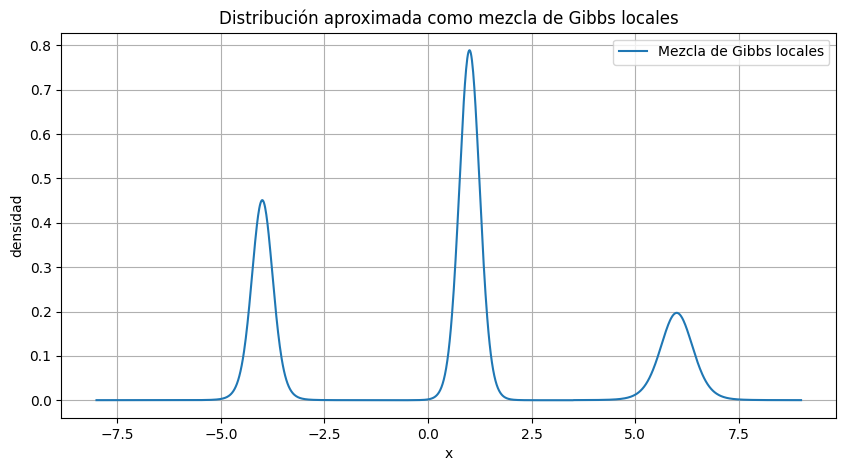

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def fitness(x):
    return (
        8  * np.exp(-(x + 4)**2)
        + 12 * np.exp(-0.7 * (x - 1)**2)
        + 7  * np.exp(-0.5 * (x - 6)**2)
    )

grid = np.linspace(-8, 9, 1200)
f_grid = fitness(grid)

# Óptimos locales aproximados
peaks = np.array([-4, 1, 6])

# Asignar cada punto de la malla a la cuenca del pico más cercano
basin_labels = np.argmin(np.abs(grid[:, None] - peaks[None, :]), axis=1)

beta = 1.0
alphas = np.array([0.3, 0.5, 0.2])  # pesos de mezcla hipotéticos

mixture = np.zeros_like(grid)

plt.figure(figsize=(10, 5))
plt.plot(grid, f_grid, color="black", label="Aptitud f(x)")

for k in range(len(peaks)):
    mask = basin_labels == k

    weights = np.exp(beta * f_grid[mask])
    Zk = np.trapezoid(weights, grid[mask])

    gibbs_local = np.zeros_like(grid)
    gibbs_local[mask] = weights / Zk

    mixture += alphas[k] * gibbs_local

    plt.fill_between(
        grid[mask],
        0,
        f_grid[mask],
        alpha=0.2,
        label=f"Cuenca B{k+1}"
    )

plt.title("Cuencas de atracción aproximadas")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(grid, mixture, label="Mezcla de Gibbs locales")
plt.title("Distribución aproximada como mezcla de Gibbs locales")
plt.xlabel("x")
plt.ylabel("densidad")
plt.legend()
plt.grid(True)
plt.show()